<h1>IMPORTAÇÕES</h1>


In [1]:
from prophet import Prophet
from prophet.diagnostics import cross_validation,performance_metrics
from prophet.plot import plot_cross_validation_metric
import pandas as pd
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

/home/henrique/miniconda3/envs/tf/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<h1>TRATAMENTO DE DADOS</h1>


In [2]:
df = pd.read_excel(
    "/home/henrique/ic-rodrigo/Controle_Faturamento_2023.xlsx",
    sheet_name="Consumo Médio - Clientes",
)

df.drop(df.iloc[:, 48:68], inplace=True, axis=1)
df.drop("Nº Cliente", inplace=True, axis=1)
df.drop("Cliente", inplace=True, axis=1)

df = df.head()

df1 = df.transpose()
df = df1.rename(columns=df1.iloc[0])
df.drop("UC", inplace=True, axis=0)
df.dropna(inplace=True)

df.index.freq = "MS"

df.reset_index(inplace=True)
df = df.rename(columns={"index": "DS"})

df.columns = ["ds", "y1", "y2", "y3", "y4", "y5"]

df["y1"] = df["y1"].astype(int)
df["y2"] = df["y2"].astype(int)
df["y3"] = df["y3"].astype(int)
df["y4"] = df["y4"].astype(int)
df["y5"] = df["y5"].astype(int)

df.columns = ["ds", "y1", "y2", "y", "y4", "y5"]

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      45 non-null     datetime64[ns]
 1   y1      45 non-null     int64         
 2   y2      45 non-null     int64         
 3   y       45 non-null     int64         
 4   y4      45 non-null     int64         
 5   y5      45 non-null     int64         
dtypes: datetime64[ns](1), int64(5)
memory usage: 2.2 KB


<h1>PREVISÕES</h1>


<h3>Previsões com train/test</h3>

In [3]:
train = df.iloc[:34]
test = df.iloc[33:]

m = Prophet(growth='flat', seasonality_mode='additive')

m.fit(train)
future = m.make_future_dataframe(periods=12,freq='MS')
forecast = m.predict(future)

08:50:19 - cmdstanpy - INFO - Chain [1] start processing
08:50:19 - cmdstanpy - INFO - Chain [1] done processing


<AxesSubplot:xlabel='ds'>

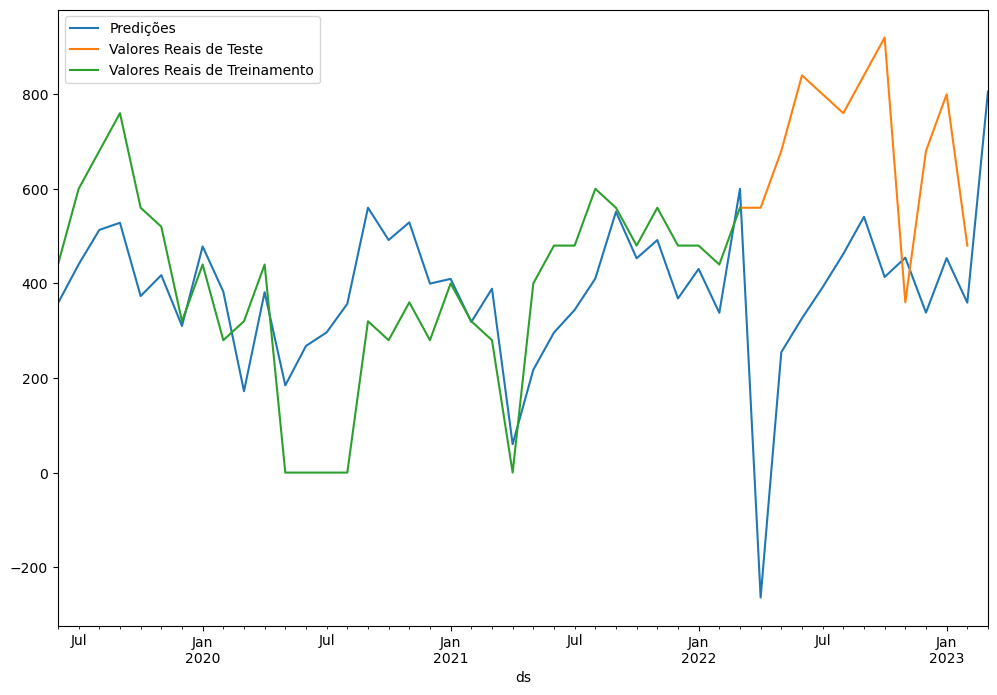

In [4]:
ax = forecast.plot(x='ds', y='yhat', label='Predições', legend=True, figsize=(12,8))
test.plot(x='ds',y='y',label='Valores Reais de Teste',legend=True,ax=ax)
train.plot(x='ds',y='y',label='Valores Reais de Treinamento',legend=True,ax=ax)

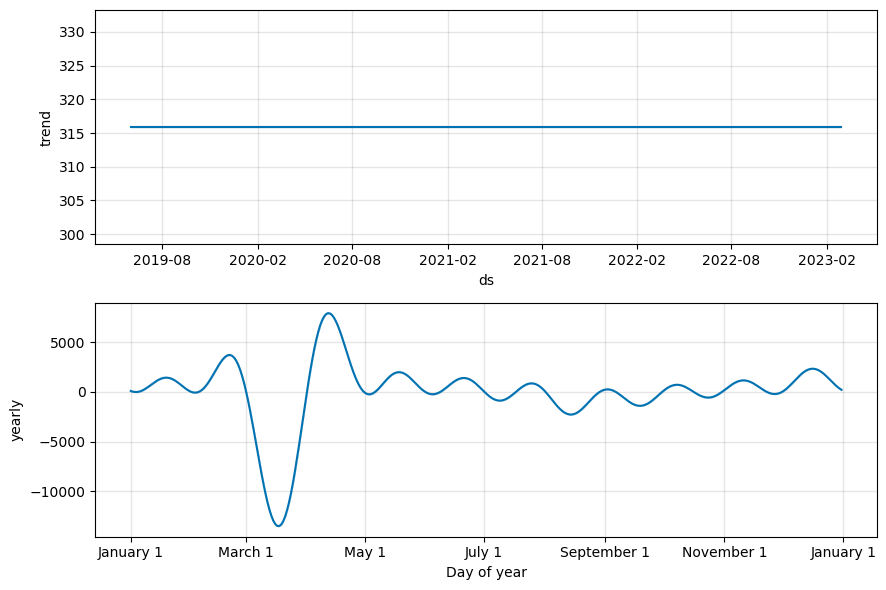

In [5]:
fig = m.plot_components(forecast);

In [6]:
initial = str(24) + ' days'

period = str(24) + ' days'

horizon = str(12) + ' days'

In [7]:
df_cv = cross_validation(m,initial=initial,period=period,horizon=horizon)

Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
  0%|          | 0/32 [00:00<?, ?it/s]

08:50:20 - cmdstanpy - INFO - Chain [1] start processing
08:50:20 - cmdstanpy - INFO - Chain [1] done processing
08:50:20 - cmdstanpy - INFO - Chain [1] start processing
08:50:20 - cmdstanpy - INFO - Chain [1] done processing
  6%|▋         | 2/32 [00:00<00:01, 15.36it/s]08:50:20 - cmdstanpy - INFO - Chain [1] start processing
08:50:20 - cmdstanpy - INFO - Chain [1] done processing
08:50:20 - cmdstanpy - INFO - Chain [1] start processing
08:50:20 - cmdstanpy - INFO - Chain [1] done processing
 12%|█▎        | 4/32 [00:00<00:03,  7.64it/s]08:50:20 - cmdstanpy - INFO - Chain [1] start processing
08:50:20 - cmdstanpy - INFO - Chain [1] done processing
08:50:20 - cmdstanpy - INFO - Chain [1] start processing
08:50:20 - cmdstanpy - INFO - Chain [1] done processing
 19%|█▉        | 6/32 [00:00<00:02,  8.70it/s]08:50:20 - cmdstanpy - INFO - Chain [1] start processing
08:50:20 - cmdstanpy - INFO - Chain [1] done processing
08:50:20 - cmdstanpy - INFO - Chain [1] start processing
08:50:21 - cmd

In [8]:
performance_metrics(df_cv)

,horizon,mse,rmse,mae,mdape,smape,coverage
0,5 days,4.899617e+07,6999.726186,4527.828398,11.450983,1.515223,0.222222
1,6 days,8.699210e+05,932.695570,598.027813,2.135908,1.054396,0.500000
2,7 days,4.049117e+06,2012.241694,1474.040853,11.521668,1.369598,0.333333
3,8 days,3.767067e+06,1940.893325,1326.091961,11.521668,1.159748,0.500000
4,12 days,9.942242e+06,3153.132057,1841.701515,2.501778,1.285049,0.200000


<h3>Previsões sem train/test</h3>

In [9]:
m = Prophet()

m.fit(df)

08:50:31 - cmdstanpy - INFO - Chain [1] start processing
08:50:31 - cmdstanpy - INFO - Chain [1] done processing


In [10]:
future = m.make_future_dataframe(periods=12,freq='MS')

forecast = m.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2019-06-01,261.947000,87.851216,566.109426,261.947000,261.947000,70.028288,70.028288,70.028288,70.028288,70.028288,70.028288,0.0,0.0,0.0,331.975288
1,2019-07-01,270.759406,128.294120,612.005550,270.759406,270.759406,94.496195,94.496195,94.496195,94.496195,94.496195,94.496195,0.0,0.0,0.0,365.255602
2,2019-08-01,279.865559,159.082502,628.892830,279.865559,279.865559,121.715739,121.715739,121.715739,121.715739,121.715739,121.715739,0.0,0.0,0.0,401.581298
3,2019-09-01,288.971713,207.285112,654.378318,288.971713,288.971713,136.799319,136.799319,136.799319,136.799319,136.799319,136.799319,0.0,0.0,0.0,425.771032
4,2019-10-01,297.784119,129.321666,617.685947,297.784119,297.784119,71.973529,71.973529,71.973529,71.973529,71.973529,71.973529,0.0,0.0,0.0,369.757648


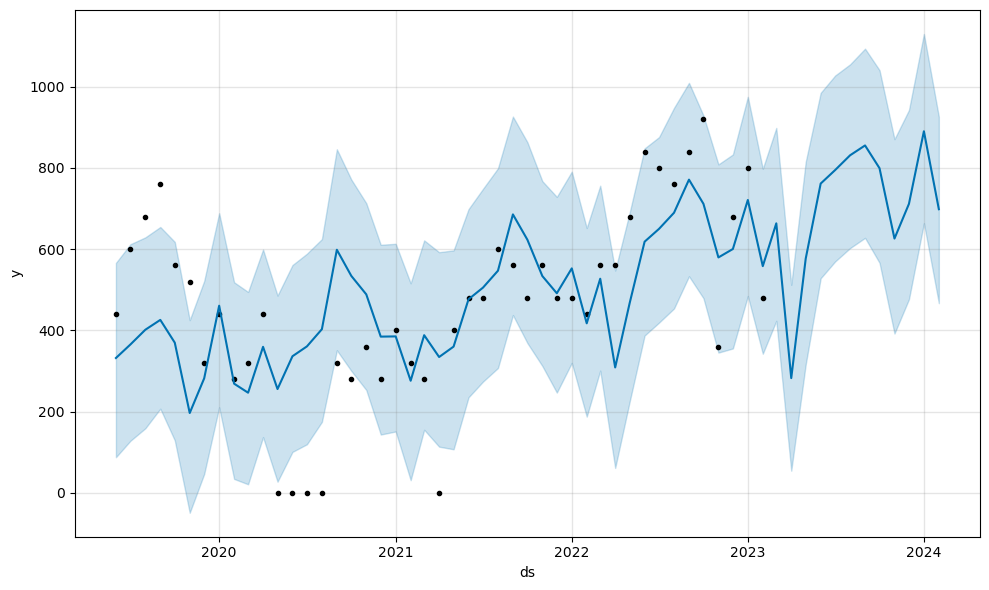

In [11]:
m.plot(forecast);

<AxesSubplot:xlabel='ds'>

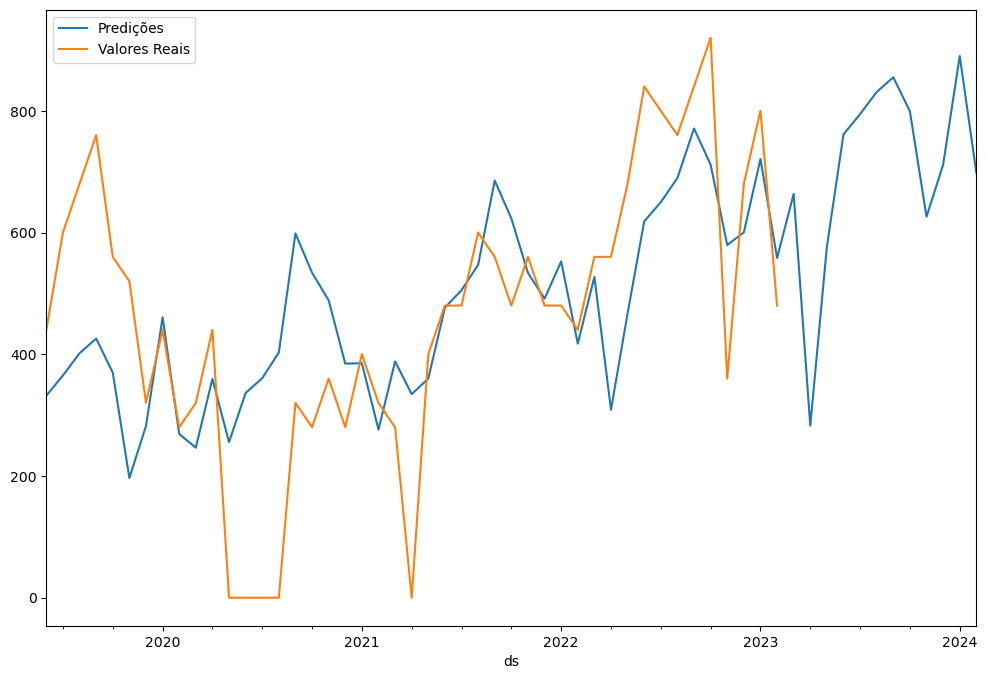

In [12]:
ax = forecast.plot(x='ds', y='yhat', label='Predições', legend=True, figsize=(12,8))
df.plot(x='ds',y='y',label='Valores Reais',legend=True,ax=ax)